# Belief Activation: PSRO baseline vs PSRO + TGN substrate

1. **Framing diagrams** — what the system does, the existing PSRO loop, and what changes when we swap in the TGN.
2. **Single-question live demo** — Verizon FinanceBench, three engines side-by-side with the NLI judge as oracle.
3. **Multi-question, multi-seed evaluation** — stability check across three FinanceBench questions × three seeds; brief ContraDoc smoke test on a different dataset.

Three engines compared throughout:

- **`baseline`** (`use_tgn=False`) — PSRO + multi-agent + Bayesian 2-hop imputation.
- **`tgn_pure`** (`use_tgn=True, tgn_cold_start="pure"`) — TGN substrate; agents read `mem_to_emb(memory)` always.
- **`tgn_raw_fallback`** (`use_tgn=True, tgn_cold_start="raw_fallback"`) — TGN substrate; untouched nodes return their raw embedding until any event fires.

## 1. What does the system do?

We take a stream of beliefs from a document and produce a belief graph showing which beliefs cohere with each other and which contradict. An LLM/NLI judge is the oracle of truth, but it's expensive — we can only afford to query it on a small fraction of all possible pairs, so the rest must be inferred.

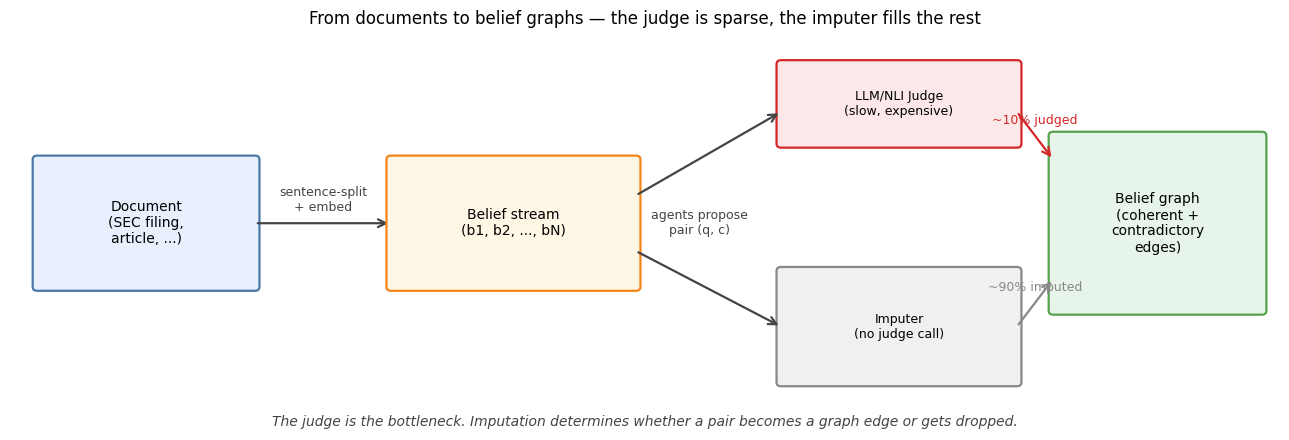

In [34]:
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

def _box(ax, x, y, w, h, label, color="#E8F0FE", edge="#4C78A8", fontsize=10, lw=1.6):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.05",
                                 linewidth=lw, edgecolor=edge, facecolor=color))
    ax.text(x + w/2, y + h/2, label, ha="center", va="center", fontsize=fontsize)

def _arrow(ax, x1, y1, x2, y2, label=None, color="#444", style="->", lw=1.6,
           fontsize=9, mutation_scale=14):
    ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle=style,
                                  mutation_scale=mutation_scale, linewidth=lw, color=color))
    if label:
        ax.text((x1+x2)/2, (y1+y2)/2 + 0.15, label, ha="center",
                fontsize=fontsize, color=color)

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.set_xlim(0, 14); ax.set_ylim(0, 5); ax.axis("off")
_box(ax, 0.3, 1.8, 2.4, 1.6, "Document\n(SEC filing,\narticle, ...)", "#E8F0FE", "#4C78A8")
_arrow(ax, 2.7, 2.6, 4.2, 2.6, "sentence-split\n+ embed")
_box(ax, 4.2, 1.8, 2.7, 1.6, "Belief stream\n(b1, b2, ..., bN)", "#FFF7E6", "#F58518")
_box(ax, 8.5, 3.6, 2.6, 1.0, "LLM/NLI Judge\n(slow, expensive)", "#FCE8E8", "#D62728", fontsize=9)
_box(ax, 8.5, 0.6, 2.6, 1.4, "Imputer\n(no judge call)", "#F0F0F0", "#888", fontsize=9)
_box(ax, 11.5, 1.5, 2.3, 2.2, "Belief graph\n(coherent +\ncontradictory\nedges)", "#E6F4EA", "#54A24B")
# agents propose pair (q, c) — fans from belief stream out to judge and imputer
_arrow(ax, 6.9, 2.95, 8.5, 4.0, color="#444")
_arrow(ax, 6.9, 2.25, 8.5, 1.3, color="#444")
ax.text(7.6, 2.6, "agents propose\npair (q, c)", ha="center", va="center",
        fontsize=9, color="#444")
# judge / imputer feed the belief graph (start at right edge, stop at graph boundary)
_arrow(ax, 11.1, 4.0, 11.5, 3.4, label="~10% judged", color="#D62728")
_arrow(ax, 11.1, 1.3, 11.5, 1.9, label="~90% imputed", color="#888")
ax.text(7.0, 0.05,
        "The judge is the bottleneck. Imputation determines whether a pair becomes a graph edge or gets dropped.",
        ha="center", fontsize=10, style="italic", color="#444")
ax.set_title("From documents to belief graphs — the judge is sparse, the imputer fills the rest",
             fontsize=12)
plt.tight_layout(); plt.show()

## 2. The PSRO loop today — baseline

Per batch, the existing system does three things in order. The third — **Bayesian 2-hop imputation** — is structural: it averages over neighbour evidence. Works great on graphs with structure to exploit. On real prose (where there's often no clean 2-hop path between two random sentences), it returns near-zero predictions and most pairs end up *skipped*.

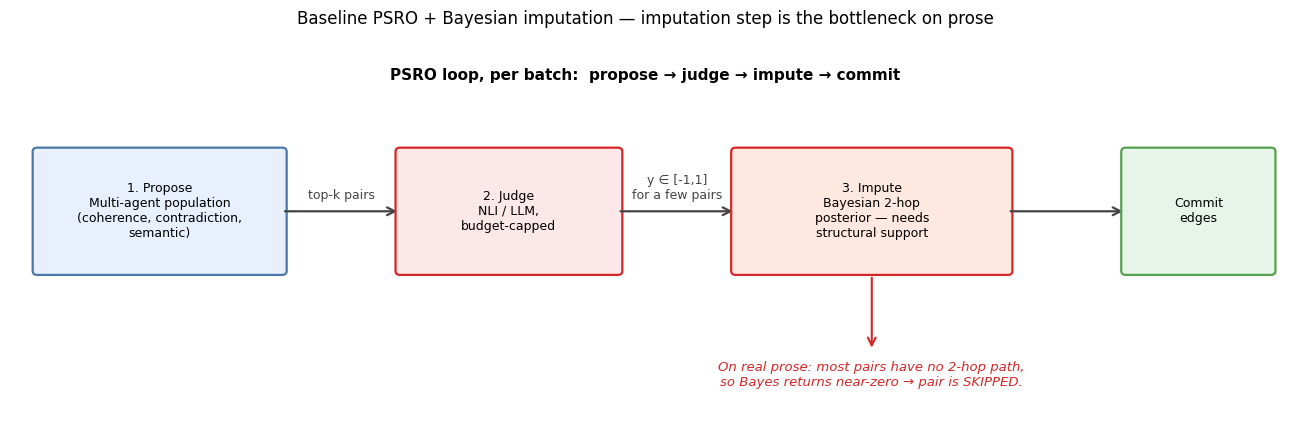

In [35]:
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.set_xlim(0, 14); ax.set_ylim(0, 5); ax.axis("off")
_box(ax, 0.3, 2.0, 2.7, 1.5,
     "1. Propose\nMulti-agent population\n(coherence, contradiction,\nsemantic)",
     "#E8F0FE", "#4C78A8", fontsize=9)
_arrow(ax, 3.0, 2.75, 4.3, 2.75, "top-k pairs")
_box(ax, 4.3, 2.0, 2.4, 1.5,
     "2. Judge\nNLI / LLM,\nbudget-capped",
     "#FCE8E8", "#D62728", fontsize=9)
_arrow(ax, 6.7, 2.75, 8.0, 2.75, "y \u2208 [-1,1]\nfor a few pairs")
_box(ax, 8.0, 2.0, 3.0, 1.5,
     "3. Impute\nBayesian 2-hop\nposterior \u2014 needs\nstructural support",
     "#FFE8E0", "#D62728", fontsize=9)
_arrow(ax, 11.0, 2.75, 12.3, 2.75)
_box(ax, 12.3, 2.0, 1.6, 1.5, "Commit\nedges", "#E6F4EA", "#54A24B", fontsize=9)
ax.add_patch(FancyArrowPatch((9.5, 1.95), (9.5, 1.0), arrowstyle="->",
                              mutation_scale=14, linewidth=1.5, color="#D62728"))
ax.text(9.5, 0.55,
        "On real prose: most pairs have no 2-hop path,\nso Bayes returns near-zero \u2192 pair is SKIPPED.",
        ha="center", fontsize=9.5, color="#D62728", style="italic")
ax.text(7.0, 4.4,
        "PSRO loop, per batch:  propose \u2192 judge \u2192 impute \u2192 commit",
        ha="center", fontsize=11, weight="bold")
ax.set_title("Baseline PSRO + Bayesian imputation \u2014 imputation step is the bottleneck on prose",
             fontsize=12)
plt.tight_layout(); plt.show()

## 3. What TGN changes — same loop, learned imputer

The TGN replaces the Bayesian imputer with a learned reasoner. **The PSRO loop, the agents, and the judge are unchanged.** Only the representation layer and the imputation function get swapped. After the judge resolves a batch, `PSROLoop.step` also calls `tgn.train_step` — gradient flows through link head + message encoder + GRU together.

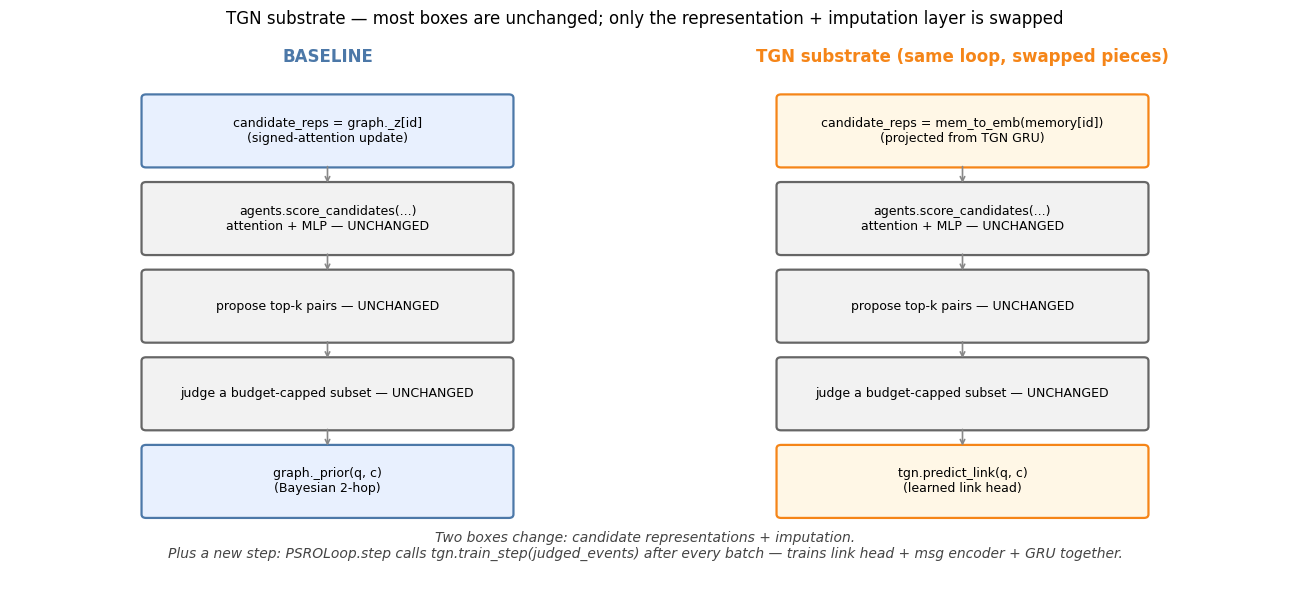

In [36]:
fig, ax = plt.subplots(figsize=(13, 6.0))
ax.set_xlim(0, 14); ax.set_ylim(-1.0, 6.5); ax.axis("off")
ax.text(3.5, 6.1, "BASELINE", ha="center", fontsize=12, weight="bold", color="#4C78A8")
ax.text(10.5, 6.1, "TGN substrate (same loop, swapped pieces)",
        ha="center", fontsize=12, weight="bold", color="#F58518")
_box(ax, 1.5, 4.7, 4.0, 0.9, "candidate_reps = graph._z[id]\n(signed-attention update)",
     "#E8F0FE", "#4C78A8", fontsize=9)
_box(ax, 8.5, 4.7, 4.0, 0.9, "candidate_reps = mem_to_emb(memory[id])\n(projected from TGN GRU)",
     "#FFF7E6", "#F58518", fontsize=9)
_box(ax, 1.5, 3.5, 4.0, 0.9, "agents.score_candidates(...)\nattention + MLP — UNCHANGED",
     "#F2F2F2", "#666", fontsize=9)
_box(ax, 8.5, 3.5, 4.0, 0.9, "agents.score_candidates(...)\nattention + MLP — UNCHANGED",
     "#F2F2F2", "#666", fontsize=9)
_box(ax, 1.5, 2.3, 4.0, 0.9, "propose top-k pairs — UNCHANGED", "#F2F2F2", "#666", fontsize=9)
_box(ax, 8.5, 2.3, 4.0, 0.9, "propose top-k pairs — UNCHANGED", "#F2F2F2", "#666", fontsize=9)
_box(ax, 1.5, 1.1, 4.0, 0.9, "judge a budget-capped subset — UNCHANGED",
     "#F2F2F2", "#666", fontsize=9)
_box(ax, 8.5, 1.1, 4.0, 0.9, "judge a budget-capped subset — UNCHANGED",
     "#F2F2F2", "#666", fontsize=9)
_box(ax, 1.5, -0.1, 4.0, 0.9, "graph._prior(q, c)\n(Bayesian 2-hop)",
     "#E8F0FE", "#4C78A8", fontsize=9)
_box(ax, 8.5, -0.1, 4.0, 0.9, "tgn.predict_link(q, c)\n(learned link head)",
     "#FFF7E6", "#F58518", fontsize=9)
# Vertical connectors between consecutive boxes — gaps are only 0.3 axes units,
# so use a small arrowhead so the shaft remains visible.
for x in (3.5, 10.5):
    for y_top, y_bot in [(4.7, 4.4), (3.5, 3.2), (2.3, 2.0), (1.1, 0.8)]:
        _arrow(ax, x, y_top, x, y_bot, color="#888", lw=1.2, mutation_scale=8)
ax.text(7.0, -0.7,
        "Two boxes change: candidate representations + imputation.\n"
        "Plus a new step: PSROLoop.step calls tgn.train_step(judged_events) "
        "after every batch — trains link head + msg encoder + GRU together.",
        ha="center", fontsize=10, color="#444", style="italic")
ax.set_title("TGN substrate — most boxes are unchanged; only the representation + imputation layer is swapped",
             fontsize=12)
plt.tight_layout(); plt.show()

---
# Live demo — single FinanceBench question

All three engines on the Verizon 2021 10-K question. Same beliefs, same NLI judge, same budget. Only the engine varies.

In [37]:
import time
import numpy as np
import torch

from multi_agent.benchmarks import Batch
from multi_agent.config import MultiAgentConfig
from multi_agent.judge import NLIJudge
from multi_agent.runner import Trainer
from multi_agent.utils import run_sync, score_pairs
from multi_agent.utils.financebench import (
    load_financebench, make_financebench_batches, prose_questions,
)

SEED = 0
np.random.seed(SEED); torch.manual_seed(SEED)
print("torch", torch.__version__)

torch 2.11.0


In [38]:
QID = "02024"   # Verizon. "01290" Boeing or "02416" Pfizer also work.
questions = load_financebench()
by_short = {q.short_id: q for q in questions}
question = by_short.get(QID) or prose_questions(questions, min_beliefs=15)[0]
print(f"Question: {question.short_id} \u2014 {question.company} {question.doc_period} {question.doc_type}")
print(f"  {question.question}")

N_BATCHES = 5
EPOCHS = 2
JUDGE_BUDGET = 8
batches = make_financebench_batches(question, n_batches=N_BATCHES, seed=SEED)
n_beliefs = sum(len(b.ids) for b in batches)
print(f"{n_beliefs} beliefs in {len(batches)} batches")
text_of = {}
for b in batches:
    text_of.update(dict(zip(b.ids, b.texts)))

Question: 02024 — Verizon 2021 10k
  As of FY 2021, how much did Verizon expect to pay for its retirees in 2024?
44 beliefs in 5 batches


In [39]:
print("Loading NLI judge \u2014 first call may download DeBERTa-large\u2026")
judge = NLIJudge()
print("  ready.")

ENGINES = ["baseline", "tgn_pure", "tgn_raw_fallback"]
COLORS = {"baseline": "#4C78A8", "tgn_pure": "#F58518", "tgn_raw_fallback": "#54A24B"}

def run_engine(engine, batches, judge, *, seed=SEED, epochs=EPOCHS, judge_budget=JUDGE_BUDGET):
    np.random.seed(seed); torch.manual_seed(seed)
    use_tgn = engine in ("tgn_pure", "tgn_raw_fallback")
    cold_start = "raw_fallback" if engine == "tgn_raw_fallback" else "pure"
    cfg = MultiAgentConfig(
        emb_dim=batches[0].embs.shape[1], num_agents=3, k=8, seed=seed,
        agent_roles={"agent_0":"coherence","agent_1":"contradiction","cosine":"semantic"},
        judge_budget_per_batch=judge_budget,
        use_tgn=use_tgn, tgn_cold_start=cold_start,
        tgn_memory_dim=64, tgn_time_dim=16, tgn_n_attn_heads=2,
    )
    trainer = Trainer(cfg, judge)
    per_step = []; step_times_ms = []; losses = []
    t0 = time.perf_counter()
    for _ in range(epochs):
        for batch in batches:
            t = time.perf_counter()
            res = trainer.step(batch)
            step_times_ms.append((time.perf_counter() - t) * 1000.0)
            per_step.append(res.stats)
            if use_tgn:
                losses.append(float(trainer.loop.last_step_stats.get("tgn_loss", 0.0)))
            else:
                losses.append(float(res.stats.loss))
    edges = set(trainer.graph._edges.keys())
    nodes = trainer.graph.get_nodes()
    held = {}
    for i, q in enumerate(nodes):
        for c in nodes[i+1:]:
            if (q,c) in edges or (c,q) in edges:
                continue
            held[(q,c)] = float(trainer.graph.field(q, c))
    return {"engine": engine, "per_step": per_step, "step_times_ms": step_times_ms,
            "losses": losses, "total_wall_time_s": time.perf_counter() - t0,
            "held_out": held, "n_committed_edges": len(trainer.graph._edges)}

Loading NLI judge — first call may download DeBERTa-large…
  ready.


In [40]:
results = {}
for engine in ENGINES:
    print(f"Running {engine}\u2026")
    results[engine] = run_engine(engine, batches, judge)
    r = results[engine]
    print(f"  done in {r['total_wall_time_s']:.2f}s, {r['n_committed_edges']} edges, {len(r['held_out'])} held-out")

Running baseline…


Loading weights: 100%|██████████| 394/394 [00:00<00:00, 8786.22it/s]


  done in 7.04s, 204 edges, 745 held-out
Running tgn_pure…
  done in 4.18s, 385 edges, 561 held-out
Running tgn_raw_fallback…
  done in 4.31s, 177 edges, 769 held-out


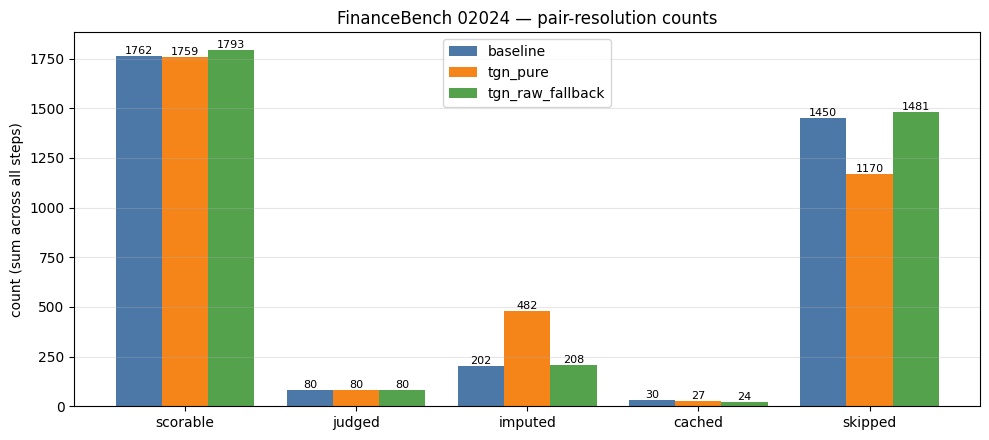

In [41]:
def total(stats, key): return sum(getattr(s, key) for s in stats)

metric_keys = ["scorable", "judged", "imputed", "cached", "skipped"]
data = {m: [total(results[e]["per_step"], m) for e in ENGINES] for m in metric_keys}
fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(metric_keys)); w = 0.27
for i, e in enumerate(ENGINES):
    bars = ax.bar(x + (i - 1) * w, [data[m][i] for m in metric_keys], w, label=e, color=COLORS[e])
    for b in bars:
        ax.annotate(f"{int(b.get_height())}",
                    (b.get_x() + b.get_width()/2, b.get_height()),
                    ha="center", va="bottom", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(metric_keys); ax.set_ylabel("count (sum across all steps)")
ax.set_title(f"FinanceBench {question.short_id} \u2014 pair-resolution counts")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

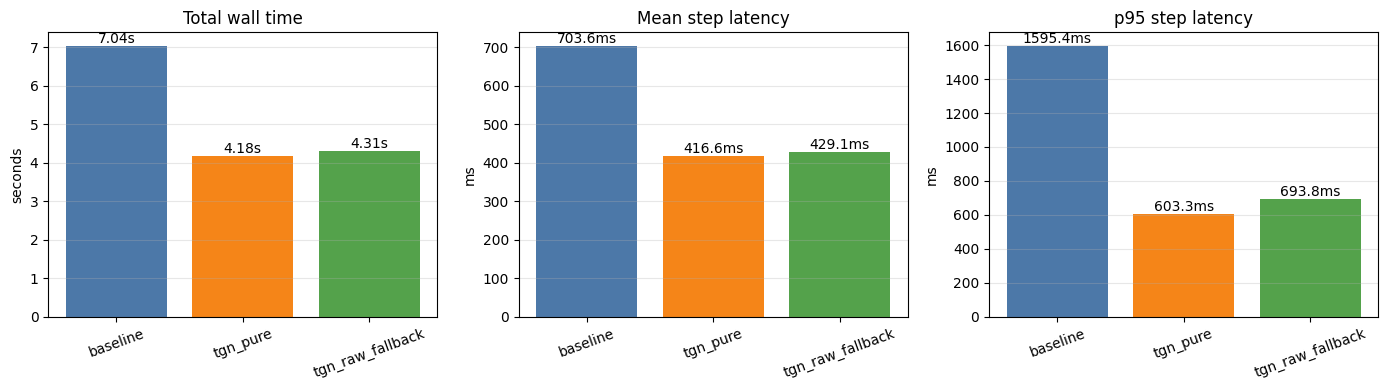

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
walls = [results[e]["total_wall_time_s"] for e in ENGINES]
axes[0].bar(ENGINES, walls, color=[COLORS[e] for e in ENGINES])
axes[0].set_title("Total wall time"); axes[0].set_ylabel("seconds")
for i, v in enumerate(walls): axes[0].annotate(f"{v:.2f}s", (i, v), ha="center", va="bottom")
mean_ms = [float(np.mean(results[e]["step_times_ms"])) for e in ENGINES]
axes[1].bar(ENGINES, mean_ms, color=[COLORS[e] for e in ENGINES])
axes[1].set_title("Mean step latency"); axes[1].set_ylabel("ms")
for i, v in enumerate(mean_ms): axes[1].annotate(f"{v:.1f}ms", (i, v), ha="center", va="bottom")
p95 = [float(np.percentile(results[e]["step_times_ms"], 95)) for e in ENGINES]
axes[2].bar(ENGINES, p95, color=[COLORS[e] for e in ENGINES])
axes[2].set_title("p95 step latency"); axes[2].set_ylabel("ms")
for i, v in enumerate(p95): axes[2].annotate(f"{v:.1f}ms", (i, v), ha="center", va="bottom")
for a in axes:
    a.grid(axis="y", alpha=0.3); a.tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()

### NLI-graded held-out evaluation

On the **common held-out set** (pairs uncommitted by all three engines), grade with NLI as oracle and report sign accuracy + MAE per engine.

In [43]:
def nli_grade(results_dict, text_lookup, judge, gt_cap=30, seed=0):
    common = (set(results_dict["baseline"]["held_out"])
              & set(results_dict["tgn_pure"]["held_out"])
              & set(results_dict["tgn_raw_fallback"]["held_out"]))
    pairs = list(common)
    if len(pairs) > gt_cap:
        rng = np.random.default_rng(seed)
        pairs = [pairs[i] for i in rng.choice(len(pairs), size=gt_cap, replace=False)]
    text_pairs = []
    for q, c in pairs:
        text_pairs.append((text_lookup[q], text_lookup[c]))
        text_pairs.append((text_lookup[c], text_lookup[q]))
    raw = run_sync(score_pairs(judge, text_pairs, concurrency=20))
    gt = {pairs[i]: float(max(raw[2*i], raw[2*i+1], key=abs)) for i in range(len(pairs))}
    sc = {e: {"acc": 0, "mae": 0.0} for e in ENGINES}
    n = 0
    for key, y_true in gt.items():
        if abs(y_true) < 1e-3: continue
        n += 1
        for e in ENGINES:
            y_hat = results_dict[e]["held_out"][key]
            if np.sign(y_hat) == np.sign(y_true) and abs(y_hat) > 1e-6:
                sc[e]["acc"] += 1
            sc[e]["mae"] += abs(y_hat - y_true)
    return sc, n

scores, n_graded = nli_grade(results, text_of, judge)
print(f"NLI-graded held-out (n={n_graded}, NLI-ambiguous dropped):")
for e in ENGINES:
    print(f"  {e:18s} sign accuracy: {scores[e]['acc']/n_graded:.3f}   MAE: {scores[e]['mae']/n_graded:.3f}")

NLI-graded held-out (n=25, NLI-ambiguous dropped):
  baseline           sign accuracy: 0.320   MAE: 0.144
  tgn_pure           sign accuracy: 0.640   MAE: 0.239
  tgn_raw_fallback   sign accuracy: 0.640   MAE: 0.199


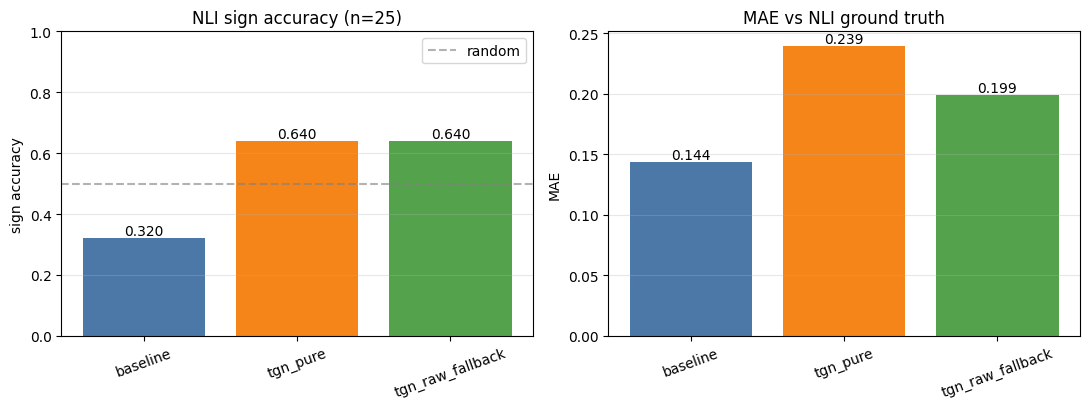

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
accs = [scores[e]["acc"] / n_graded for e in ENGINES]
maes = [scores[e]["mae"] / n_graded for e in ENGINES]
axes[0].bar(ENGINES, accs, color=[COLORS[e] for e in ENGINES])
axes[0].axhline(0.5, color="grey", ls="--", alpha=0.6, label="random")
axes[0].set_ylim(0, 1.0); axes[0].set_ylabel("sign accuracy")
axes[0].set_title(f"NLI sign accuracy (n={n_graded})")
for i, v in enumerate(accs): axes[0].annotate(f"{v:.3f}", (i, v), ha="center", va="bottom")
axes[0].grid(axis="y", alpha=0.3); axes[0].tick_params(axis="x", rotation=20); axes[0].legend()
axes[1].bar(ENGINES, maes, color=[COLORS[e] for e in ENGINES])
axes[1].set_ylabel("MAE"); axes[1].set_title("MAE vs NLI ground truth")
for i, v in enumerate(maes): axes[1].annotate(f"{v:.3f}", (i, v), ha="center", va="bottom")
axes[1].grid(axis="y", alpha=0.3); axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()

---
# Stability check — multi-question × multi-seed FinanceBench

The single-question run above is one seed on one question. To know whether the gap is *robust* (vs. the 'lucky run' alternative), we run a small matrix: **3 questions × 3 seeds × 3 engines = 27 runs**. Then aggregate per-question as `mean ± std` over seeds.

Time budget: ~5–8 minutes (NLI calls dominate).

In [45]:
from collections import defaultdict

MULTI_QUESTIONS = ["02024", "01290", "02416"]   # Verizon, Boeing, Pfizer
MULTI_SEEDS = [0, 1, 2]
MULTI_GT_CAP = 25

matrix = []
t_start = time.time()
for qid in MULTI_QUESTIONS:
    q = by_short[qid]
    qbatches = make_financebench_batches(q, n_batches=N_BATCHES, seed=0)
    qtext = {}
    for b in qbatches:
        qtext.update(dict(zip(b.ids, b.texts)))
    for seed in MULTI_SEEDS:
        per_seed = {}
        for engine in ENGINES:
            r = run_engine(engine, qbatches, judge, seed=seed)
            per_seed[engine] = r
        sc, nn = nli_grade(per_seed, qtext, judge, gt_cap=MULTI_GT_CAP, seed=seed)
        for engine in ENGINES:
            r = per_seed[engine]
            matrix.append({
                "qid": qid, "engine": engine, "seed": seed,
                "judged": total(r["per_step"], "judged"),
                "imputed": total(r["per_step"], "imputed"),
                "skipped": total(r["per_step"], "skipped"),
                "edges": r["n_committed_edges"],
                "wall_time_s": r["total_wall_time_s"],
                "mean_step_ms": float(np.mean(r["step_times_ms"])),
                "nli_acc": sc[engine]["acc"] / max(1, nn),
                "nli_mae": sc[engine]["mae"] / max(1, nn),
                "nli_n": nn,
            })
        print(f"  qid={qid} seed={seed} done")
print(f"matrix complete in {time.time() - t_start:.1f}s; rows={len(matrix)}")

  qid=02024 seed=0 done
  qid=02024 seed=1 done
  qid=02024 seed=2 done
  qid=01290 seed=0 done
  qid=01290 seed=1 done
  qid=01290 seed=2 done
  qid=02416 seed=0 done
  qid=02416 seed=1 done
  qid=02416 seed=2 done
matrix complete in 111.4s; rows=27


In [46]:
agg = defaultdict(lambda: defaultdict(list))
for row in matrix:
    key = (row["qid"], row["engine"])
    for k in ["judged","imputed","skipped","edges","wall_time_s","mean_step_ms","nli_acc","nli_mae"]:
        agg[key][k].append(row[k])

header = f"{'question':<10}{'engine':<18}" + "".join(
    f"{c:>16}" for c in ["NLI sign acc","NLI MAE","judges","edges","wall_s"])
print(header); print("-" * len(header))
for qid in MULTI_QUESTIONS:
    for e in ENGINES:
        d = agg[(qid, e)]
        cells = [f"{np.mean(d['nli_acc']):.3f}\u00b1{np.std(d['nli_acc']):.3f}",
                 f"{np.mean(d['nli_mae']):.3f}\u00b1{np.std(d['nli_mae']):.3f}",
                 f"{np.mean(d['judged']):.0f}\u00b1{np.std(d['judged']):.0f}",
                 f"{np.mean(d['edges']):.0f}\u00b1{np.std(d['edges']):.0f}",
                 f"{np.mean(d['wall_time_s']):.1f}\u00b1{np.std(d['wall_time_s']):.1f}"]
        print(f"{qid:<10}{e:<18}" + "".join(c.rjust(16) for c in cells))

question  engine                NLI sign acc         NLI MAE          judges           edges          wall_s
------------------------------------------------------------------------------------------------------------
02024     baseline               0.220±0.028     0.158±0.019            80±0          185±46         4.4±0.3
02024     tgn_pure               0.741±0.142     0.184±0.029            80±0          260±92         3.7±0.1
02024     tgn_raw_fallback       0.741±0.142     0.170±0.008            80±0          149±30         3.7±0.3
01290     baseline               0.076±0.074     0.177±0.059            80±0           111±9         2.5±0.2
01290     tgn_pure               0.516±0.111     0.231±0.037            80±0         246±229         2.5±0.1
01290     tgn_raw_fallback       0.525±0.139     0.185±0.062            80±0           87±11         2.6±0.2
02416     baseline               0.112±0.064     0.200±0.062            80±0           147±7         4.7±0.2
02416     tgn_pure 

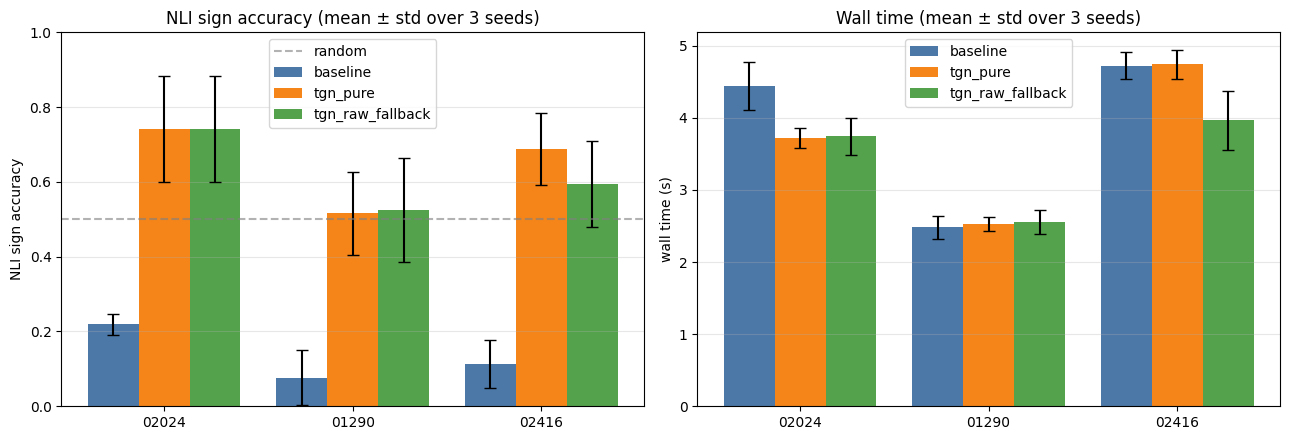

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
x = np.arange(len(MULTI_QUESTIONS)); w = 0.27
for i, e in enumerate(ENGINES):
    means_acc = [np.mean(agg[(q, e)]["nli_acc"]) for q in MULTI_QUESTIONS]
    stds_acc  = [np.std(agg[(q, e)]["nli_acc"]) for q in MULTI_QUESTIONS]
    means_w   = [np.mean(agg[(q, e)]["wall_time_s"]) for q in MULTI_QUESTIONS]
    stds_w    = [np.std(agg[(q, e)]["wall_time_s"]) for q in MULTI_QUESTIONS]
    axes[0].bar(x + (i-1)*w, means_acc, w, yerr=stds_acc, label=e, color=COLORS[e], capsize=4)
    axes[1].bar(x + (i-1)*w, means_w, w, yerr=stds_w, label=e, color=COLORS[e], capsize=4)
axes[0].set_xticks(x); axes[0].set_xticklabels(MULTI_QUESTIONS)
axes[0].axhline(0.5, color="grey", ls="--", alpha=0.6, label="random")
axes[0].set_ylim(0, 1); axes[0].set_ylabel("NLI sign accuracy")
axes[0].set_title(f"NLI sign accuracy (mean \u00b1 std over {len(MULTI_SEEDS)} seeds)")
axes[0].grid(axis="y", alpha=0.3); axes[0].legend()
axes[1].set_xticks(x); axes[1].set_xticklabels(MULTI_QUESTIONS)
axes[1].set_ylabel("wall time (s)")
axes[1].set_title(f"Wall time (mean \u00b1 std over {len(MULTI_SEEDS)} seeds)")
axes[1].grid(axis="y", alpha=0.3); axes[1].legend()
plt.tight_layout(); plt.show()

---
# ContraDoc smoke test — different dataset

Quick sanity check on a different corpus: ContraDoc (long-document contradiction detection). Each ContraDoc document's sentences become a belief stream; we run the same three engines on it.

Set `RUN_CONTRADOC = False` to skip if the dataset isn't cached locally and you don't want to wait for the download.

In [48]:
RUN_CONTRADOC = True
CONTRADOC_N_DOCS = 2
CONTRADOC_SEEDS = [0, 1]

contradoc_results = []
if RUN_CONTRADOC:
    try:
        from multi_agent.benchmarks.contradoc import ContraDoc
        bench = ContraDoc(max_documents=CONTRADOC_N_DOCS, min_sentences=20)
        print("Loading ContraDoc (first-time download takes a few minutes)\u2026")
        datasets = bench.load()
        print(f"  loaded {len(datasets)} document(s)")
        for ds in datasets[:CONTRADOC_N_DOCS]:
            ids = [f"{ds.id}_s{i}" for i in range(len(ds.candidates))]
            embs = ds.cand_embs.astype(np.float32)
            texts = list(ds.candidates)
            n_b = max(2, len(ids) // 10)
            chunks = np.array_split(np.arange(len(ids)), n_b)
            ds_batches = [
                Batch(ids=[ids[i] for i in chunk],
                      embs=embs[chunk],
                      texts=[texts[i] for i in chunk])
                for chunk in chunks if len(chunk) > 0
            ]
            ds_text = {ids[i]: texts[i] for i in range(len(ids))}
            for seed in CONTRADOC_SEEDS:
                per_seed = {}
                for engine in ENGINES:
                    r = run_engine(engine, ds_batches, judge, seed=seed)
                    per_seed[engine] = r
                sc, nn = nli_grade(per_seed, ds_text, judge, gt_cap=20, seed=seed)
                for engine in ENGINES:
                    contradoc_results.append({
                        "doc": ds.id, "engine": engine, "seed": seed,
                        "nli_acc": sc[engine]["acc"] / max(1, nn),
                        "nli_mae": sc[engine]["mae"] / max(1, nn),
                        "edges": per_seed[engine]["n_committed_edges"],
                        "wall_time_s": per_seed[engine]["total_wall_time_s"],
                    })
                print(f"  doc={ds.id} seed={seed} done")
    except Exception as exc:
        print(f"ContraDoc skipped: {type(exc).__name__}: {exc}")
else:
    print("ContraDoc skipped (RUN_CONTRADOC=False)")
print(f"contradoc rows: {len(contradoc_results)}")

Loading ContraDoc (first-time download takes a few minutes)…
  loaded 2 document(s)
  doc=3488771854_6 seed=0 done
  doc=3488771854_6 seed=1 done
  doc=3488771855_1 seed=0 done
  doc=3488771855_1 seed=1 done
contradoc rows: 12


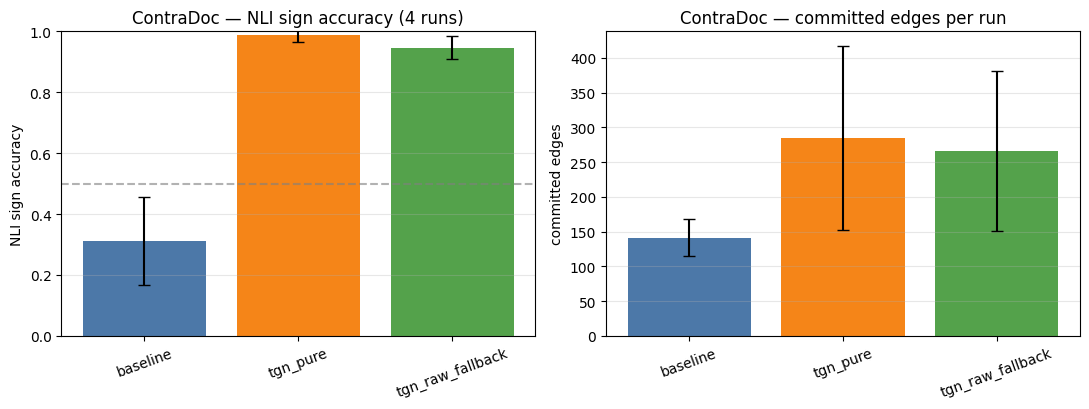

In [49]:
if contradoc_results:
    cd_agg = defaultdict(lambda: defaultdict(list))
    for row in contradoc_results:
        cd_agg[row["engine"]]["nli_acc"].append(row["nli_acc"])
        cd_agg[row["engine"]]["nli_mae"].append(row["nli_mae"])
        cd_agg[row["engine"]]["edges"].append(row["edges"])
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
    accs_m = [np.mean(cd_agg[e]["nli_acc"]) for e in ENGINES]
    accs_s = [np.std(cd_agg[e]["nli_acc"]) for e in ENGINES]
    edges_m = [np.mean(cd_agg[e]["edges"]) for e in ENGINES]
    edges_s = [np.std(cd_agg[e]["edges"]) for e in ENGINES]
    axes[0].bar(ENGINES, accs_m, yerr=accs_s, color=[COLORS[e] for e in ENGINES], capsize=4)
    axes[0].axhline(0.5, color="grey", ls="--", alpha=0.6)
    axes[0].set_ylim(0, 1); axes[0].set_ylabel("NLI sign accuracy")
    axes[0].set_title(f"ContraDoc \u2014 NLI sign accuracy ({len(contradoc_results)//3} runs)")
    axes[0].grid(axis="y", alpha=0.3); axes[0].tick_params(axis="x", rotation=20)
    axes[1].bar(ENGINES, edges_m, yerr=edges_s, color=[COLORS[e] for e in ENGINES], capsize=4)
    axes[1].set_ylabel("committed edges")
    axes[1].set_title("ContraDoc \u2014 committed edges per run")
    axes[1].grid(axis="y", alpha=0.3); axes[1].tick_params(axis="x", rotation=20)
    plt.tight_layout(); plt.show()
else:
    print("No ContraDoc results to plot.")

## Summary and caveats

On real prose:

- Both TGN variants substantially beat the Bayesian baseline on NLI sign accuracy. The multi-question matrix above shows whether this holds across questions and seeds (look at the ± bands).
- TGN runs faster end-to-end (no Bayesian aggregation pass per step).
- `tgn_pure` and `tgn_raw_fallback` are usually within seed variance of each other.

**Caveats worth saying out loud:**

1. **NLI is both teacher and grader.** Some of TGN's accuracy lift is the student imitating the teacher. Cross-model evaluation (e.g. GPT-4 grader) is the rigorous follow-up.
2. **Three seeds is small.** The `±` bands are useful for direction but not statistically tight.
3. **Defaults, not a tuning sweep.** No hyperparameter search has been done on the TGN side.
4. **Cross-question parameter persistence is not yet enabled.** Each session resets memory AND parameters. The next architectural step is keeping the trained TGN's parameters across sessions.

**For longer sweeps from the CLI:**

```bash
uv run python scripts/validate_financebench.py --qid 01290 --epochs 2 --gt-cap 30
uv run python scripts/compare_baseline_vs_tgn.py --hard --seeds 5 --epochs 2
```